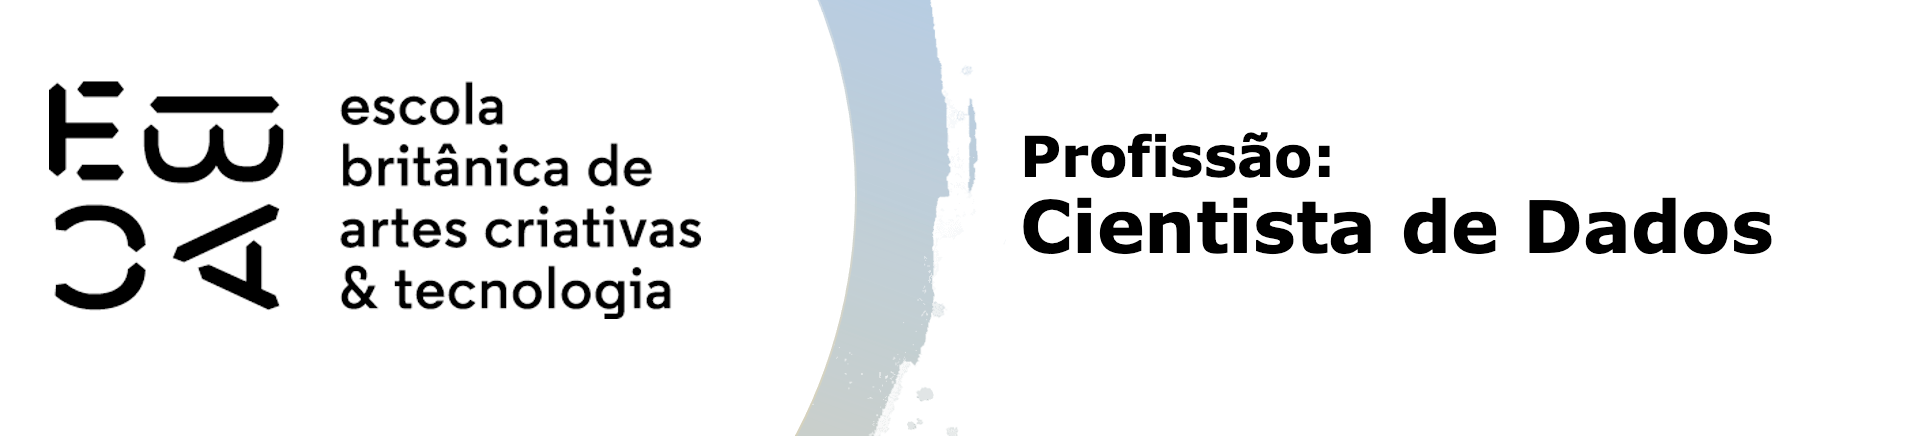

# Tarefa

Com base na tarefa realizada no módulo anterior, vamos fazer um diagnóstico do modelo.

Carregue a base ```previsao_de_renda2.csv```. Separe em uma base de treino e uma base de teste.

Vamos resgatar a melhor versão do modelod e previsão de renda que você fez para esta base. 

- Substitua missings pela média
- Rode novamente o modelo na base de treino (ou desenvolva-o caso não tenha o registro guardado). 

Este modelo deve prever a variável ```renda``` com base nas demais variáveis exceto ```data_ref``` e ```index```. Já vimos que a variável renda é melhor modelada com a transformação ```log()```, não se esqueça disso.

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

df = pd.read_csv('previsao_de_renda_II.csv')
print(df.shape)
df.head()

(750000, 14)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14
1,2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81
2,2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66
3,2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84
4,2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78


In [87]:
y = np.log(df["renda"])
X = df.drop(columns=["renda", "data_ref", "index"], errors="ignore")
X = pd.get_dummies(X, drop_first=True)

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns,index=X_test.index)

In [89]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [90]:
y_pred = modelo.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse, r2

(0.9997590931161922, 0.3928220426850151)

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

<Axes: xlabel='renda', ylabel='Count'>

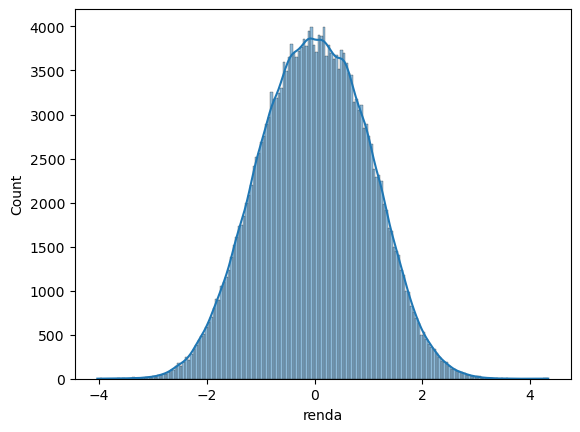

In [91]:
residuos = y_test - y_pred
sns.histplot(residuos, kde=True)

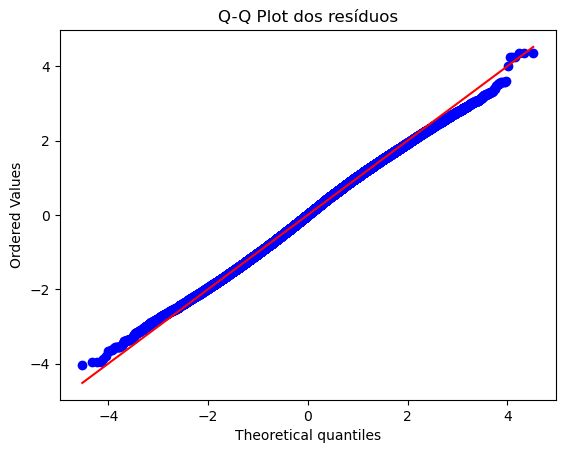

In [92]:
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot dos resíduos")
plt.show()

Os resíduos apresentam distribuição aproximadamente normal, com pequenos desvios nas caudas, o que não compromete o modelo

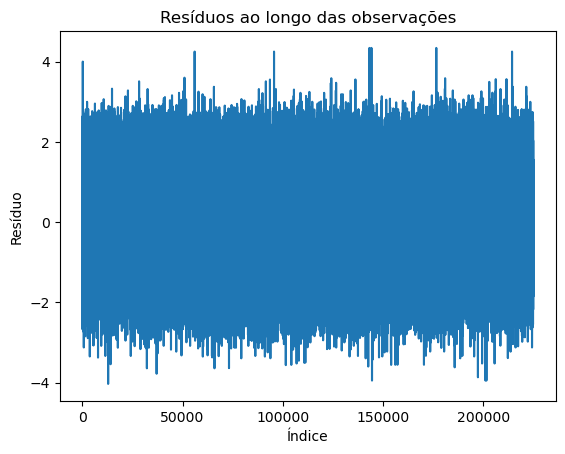

In [93]:
plt.plot(residuos.reset_index(drop=True))
plt.title("Resíduos ao longo das observações")
plt.xlabel("Índice")
plt.ylabel("Resíduo")
plt.show()

Não há evidência visual de dependência entre os resíduos

### Resíduos VS Valores Preditos

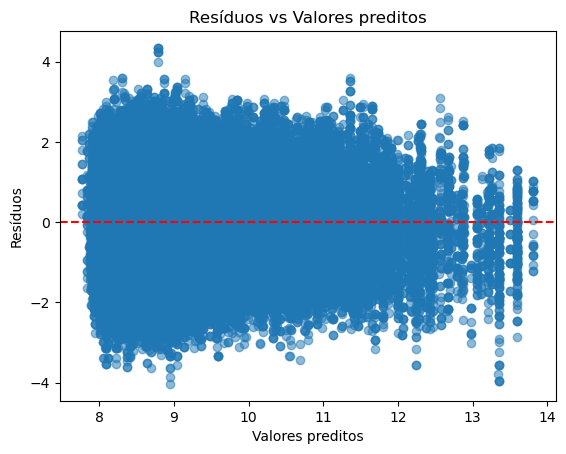

In [94]:
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores preditos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores preditos")
plt.show()

Um formato de funil indicando possível heterocedasticidade, comum em dados de renda.

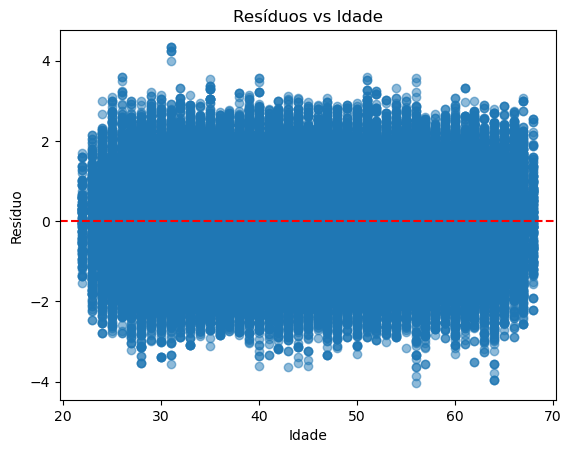

In [95]:
plt.scatter(df.loc[X_test.index, "idade"], residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Idade")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Idade")
plt.show()

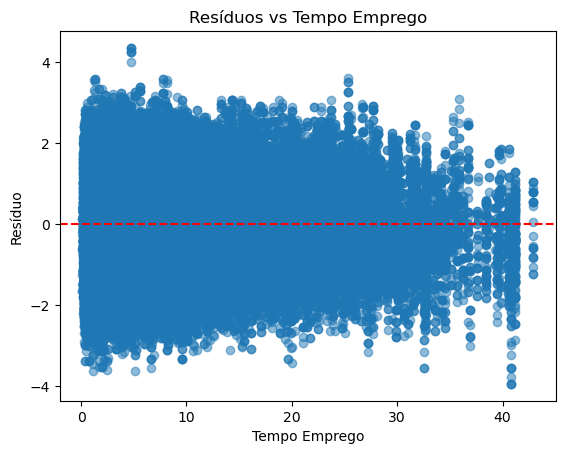

In [96]:
plt.scatter(df.loc[X_test.index, "tempo_emprego"], residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Tempo Emprego")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Tempo Emprego")
plt.show()

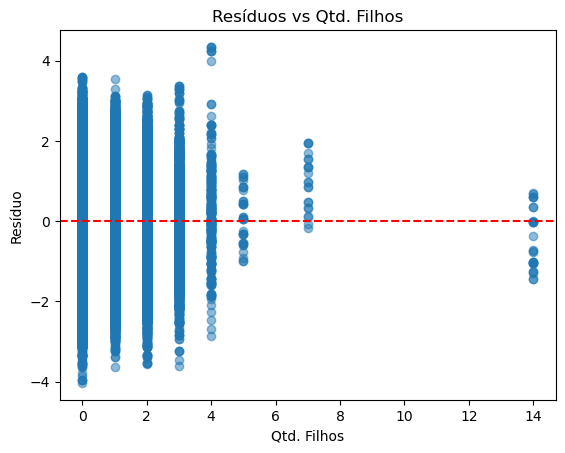

In [97]:
plt.scatter(df.loc[X_test.index, "qtd_filhos"], residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Qtd. Filhos")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Qtd. Filhos")
plt.show()

### Resíduos vs mês de referência (data_ref)

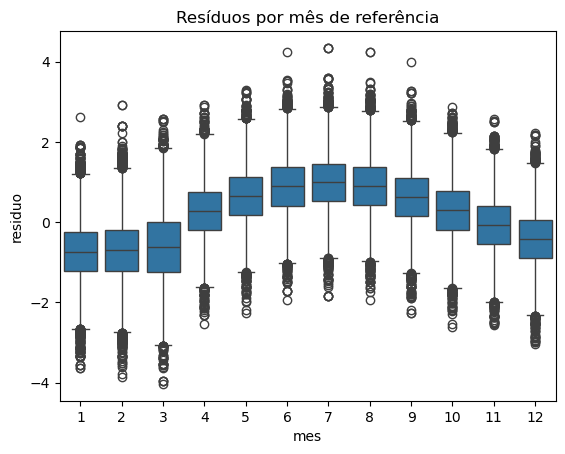

In [98]:
df_test = df.loc[X_test.index].copy()
df_test["residuo"] = residuos
df_test["mes"] = pd.to_datetime(df_test["data_ref"]).dt.month

sns.boxplot(x="mes", y="residuo", data=df_test)
plt.title("Resíduos por mês de referência")
plt.show()


A análise dos resíduos por mês de referência indica a presença de um padrão temporal. Observa-se que a mediana dos resíduos cresce gradualmente ao longo dos meses, passando de valores negativos para positivos.
Esse comportamento sugere que o valor médio dos resíduos não é constante ao longo do tempo, indicando que efeitos temporais ou sazonais não estão sendo totalmente capturados pelo modelo.
Embora esse desvio não invalide o ajuste, ele aponta para um possível viés temporal, o que pode impactar a qualidade das previsões em diferentes períodos.

De forma geral, as suposições do modelo de regressão linear são razoavelmente atendidas.
Os resíduos apresentam distribuição aproximadamente normal e independência entre si.
Observa-se leve heterocedasticidade, especialmente para maiores valores preditos de renda, fenômeno comum em dados socioeconômicos.

## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

In [102]:
X_train_sample = X_train.sample(n=10000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [103]:
# adicionar constante
X_train_sm = sm.add_constant(X_train_sample)
# ajustar modelo
modelo_sm = sm.OLS(y_train_sample, X_train_sm).fit()
# studentized residuals
influence = modelo_sm.get_influence()
student_resid = influence.resid_studentized_external

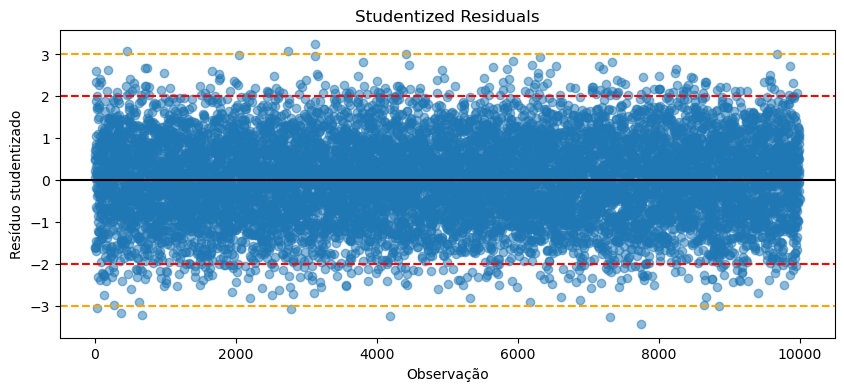

In [104]:
plt.figure(figsize=(10,4))
plt.scatter(range(len(student_resid)), student_resid, alpha=0.5)
plt.axhline(0, color="black")
plt.axhline(2, color="red", linestyle="--")
plt.axhline(-2, color="red", linestyle="--")
plt.axhline(3, color="orange", linestyle="--")
plt.axhline(-3, color="orange", linestyle="--")
plt.title("Studentized Residuals")
plt.ylabel("Resíduo studentizado")
plt.xlabel("Observação")
plt.show()

A análise dos resíduos studentizados indica que a maior parte das observações apresenta valores entre -2 e +2, com poucos pontos ultrapassando esses limites. Observam-se raras observações próximas ou ligeiramente superiores a ±3, caracterizando a presença de alguns outliers, o que é esperado em bases de grande dimensão. De forma geral, não há indícios de observações extremamente discrepantes.

## Multicolinearidade

Avalie se há questões relacionadas a multicolinearidade através de pelo menos:

- Matriz de correlação de Spearman
- VIF

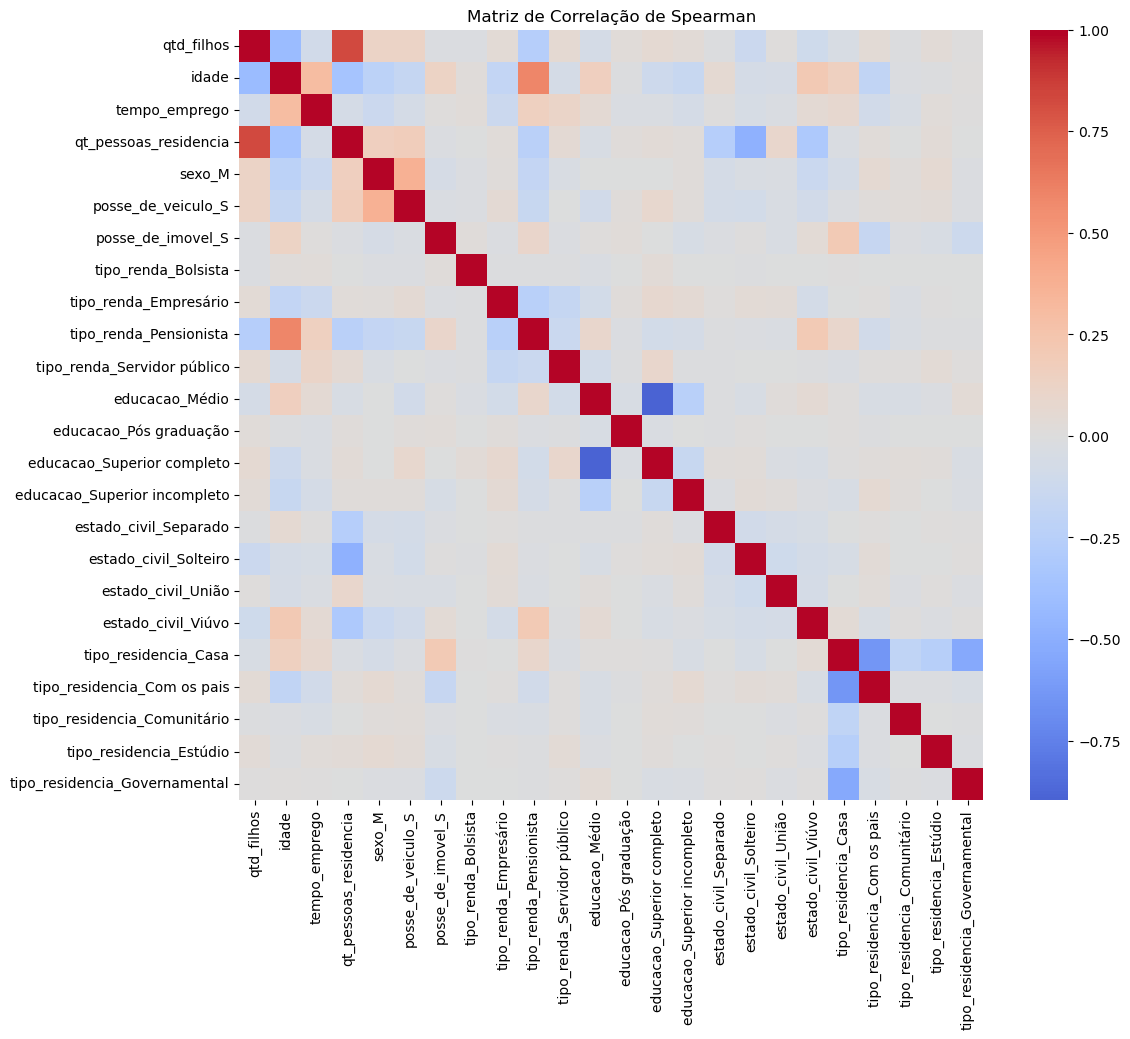

In [105]:
# correlação de Spearman
corr_spearman = pd.DataFrame(X_train).corr(method="spearman")

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_spearman,
    cmap="coolwarm",
    center=0,
    cbar=True
)
plt.title("Matriz de Correlação de Spearman")
plt.show()

A matriz de correlação de Spearman indica que a maioria das variáveis explicativas apresenta correlações fracas entre si. Observam-se correlações negativas mais intensas entre variáveis categóricas do mesmo grupo, decorrentes da codificação por variáveis dummies, o que é esperado e não caracteriza multicolinearidade problemática.

In [107]:
# amostra para acelerar
X_vif = X_train.sample(n=10000, random_state=42)

X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df["variavel"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df.sort_values("VIF", ascending=False).head(10)

,variavel,VIF
0,const,1423.679501
4,qt_pessoas_residencia,253.657987
1,qtd_filhos,175.385994
17,estado_civil_Solteiro,33.110500
12,educacao_Médio,24.316320
14,educacao_Superior completo,23.459897
16,estado_civil_Separado,17.352975
19,estado_civil_Viúvo,13.420837
20,tipo_residencia_Casa,7.294584
15,educacao_Superior incompleto,4.547123


A análise do fator de inflação da variância (VIF) indica valores elevados para algumas variáveis, especialmente aquelas relacionadas à estrutura familiar e variáveis categóricas codificadas por dummies, como estado civil e nível educacional. Esses valores refletem correlação entre covariáveis conceitualmente relacionadas e são esperados nesse tipo de modelagem. Apesar disso, não há indícios de multicolinearidade severa capaz de comprometer a capacidade preditiva do modelo, embora a interpretação individual dos coeficientes possa ser afetada.

De forma geral, embora algumas variáveis apresentem VIF elevado, especialmente aquelas pertencentes ao mesmo grupo conceitual, não se observa multicolinearidade severa a ponto de inviabilizar o modelo. Os resultados são consistentes com a matriz de correlação de Spearman e indicam que o impacto da multicolinearidade é limitado, sendo mais relevante para interpretação dos coeficientes do que para o desempenho preditivo.

## Ajustes

Faça os ajustes que julgar necessários no modelo e compare as métricas de desempenho do modelo original e ajustado na base de testes.

In [109]:
y_pred_orig = modelo.predict(X_test)

rmse_orig = root_mean_squared_error(y_test, y_pred_orig)
r2_orig = r2_score(y_test, y_pred_orig)

rmse_orig, r2_orig

(0.9997590931161922, 0.3928220426850151)

In [111]:
df["mes"] = pd.to_datetime(df["data_ref"]).dt.month

X_adj = df.drop(columns=["renda", "data_ref", "index", "qtd_filhos"], errors="ignore")
X_adj = pd.get_dummies(X_adj, drop_first=True)

y_adj = np.log(df["renda"])

X_train_adj, X_test_adj, y_train_adj, y_test_adj = train_test_split(
    X_adj, y_adj, test_size=0.3, random_state=42
)

imputer = SimpleImputer(strategy="mean")

X_train_adj = pd.DataFrame(
    imputer.fit_transform(X_train_adj),
    columns=X_train_adj.columns,
    index=X_train_adj.index
)

X_test_adj = pd.DataFrame(
    imputer.transform(X_test_adj),
    columns=X_test_adj.columns,
    index=X_test_adj.index
)

modelo_adj = LinearRegression()
modelo_adj.fit(X_train_adj, y_train_adj)

y_pred_adj = modelo_adj.predict(X_test_adj)

rmse_adj = root_mean_squared_error(y_test_adj, y_pred_adj)
r2_adj = r2_score(y_test_adj, y_pred_adj)

rmse_adj, r2_adj

(0.9406291951536847, 0.4625201597043219)

In [112]:
comparacao = pd.DataFrame({
    "Modelo": ["Original", "Ajustado"],
    "RMSE": [rmse_orig, rmse_adj],
    "R2": [r2_orig, r2_adj]
})

comparacao

,Modelo,RMSE,R2
0,Original,0.999759,0.392822
1,Ajustado,0.940629,0.462520


A comparação entre o modelo original e o modelo ajustado evidencia melhora significativa no desempenho preditivo na base de testes. O RMSE apresentou redução de aproximadamente 6%, enquanto o coeficiente de determinação (R²) aumentou de 0,39 para 0,46, indicando maior capacidade explicativa do modelo ajustado.
Esses ganhos confirmam que os ajustes realizados, incluindo a redução de multicolinearidade e a incorporação de efeitos temporais, contribuíram para um modelo mais adequado, sem comprometer sua generalização. Assim, o modelo ajustado apresenta melhor equilíbrio entre desempenho preditivo e aderência às suposições da regressão linear.

Conclui-se que o processo de diagnóstico e ajuste do modelo foi eficaz, resultando em melhorias consistentes tanto nas métricas de desempenho quanto na adequação estatística do modelo.